# HMLN preprocess

Prepare the data for training.


## Settings


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
                    if (path / "experiments").is_dir() and (path / "lrpairs").is_dir())
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

scanvi_train_kwargs = {"accelerator": "gpu", "devices": 1, "enable_progress_bar": False}
from pathlib import Path
import yaml

DATASET = 'HMLN'
CWD = Path.cwd().resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").is_file() else CWD / "experiments" / DATASET
REPO_ROOT = EXPERIMENT_DIR.parents[1]
import sys

CONFIG = yaml.safe_load(
    (EXPERIMENT_DIR / "config.yaml").read_text(encoding="utf-8")
)

def experiment_path(value):
    path = Path(value)
    return path if path.is_absolute() else (EXPERIMENT_DIR / path).resolve()

DATA_ROOT = experiment_path(CONFIG["data_root"])
RUN_ROOT = experiment_path(CONFIG["run_root"])
CHECKPOINT_ROOT = experiment_path(CONFIG["checkpoint_root"])
SCANVI_DIR = experiment_path(CONFIG["scanvi_dir"])
SCANVI_ADATA = SCANVI_DIR / "adata.h5ad"
LR_PAIRS = experiment_path(CONFIG["lr_pairs_path"])
TRANSITION_PRIOR = experiment_path(CONFIG["transition_prior_path"]) if "transition_prior_path" in CONFIG else None
DATA_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)


from _shared.preprocess_plots import annotation_palette, sample_panels, alignment_overlay, embedding_panels


In [2]:
import os
import numpy as np
import anndata as ad
import scanpy as sc
import scvi
import sys


## Prepare data


In [3]:
# Read original filenames; rename sample metadata once at ingestion.
from stvirtual.data.hmln import load_hmln
adata = load_hmln(DATA_ROOT / "raw", CONFIG["sample_mapping"])
print(adata.obs[["sample_original", "sample"]].drop_duplicates())
if "raw" not in adata.layers:
    raise KeyError("HMLN input must contain raw count layer 'raw'")
adata.layers["counts"] = adata.layers["raw"].copy()


        sample_original sample
307-S1               S2     S1
692-S2               S3     S2
2434-S3              S4     S3


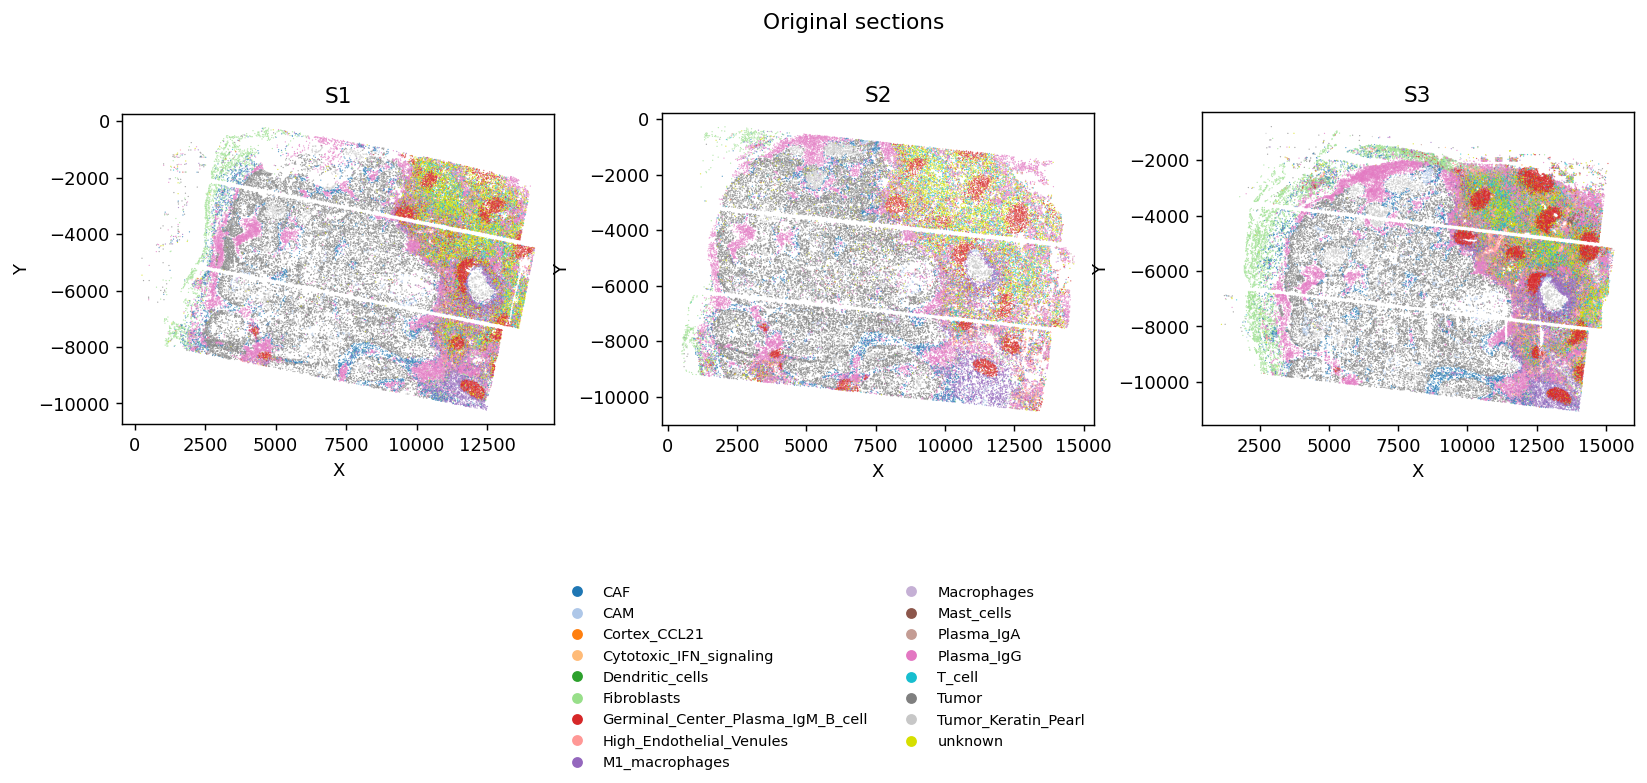

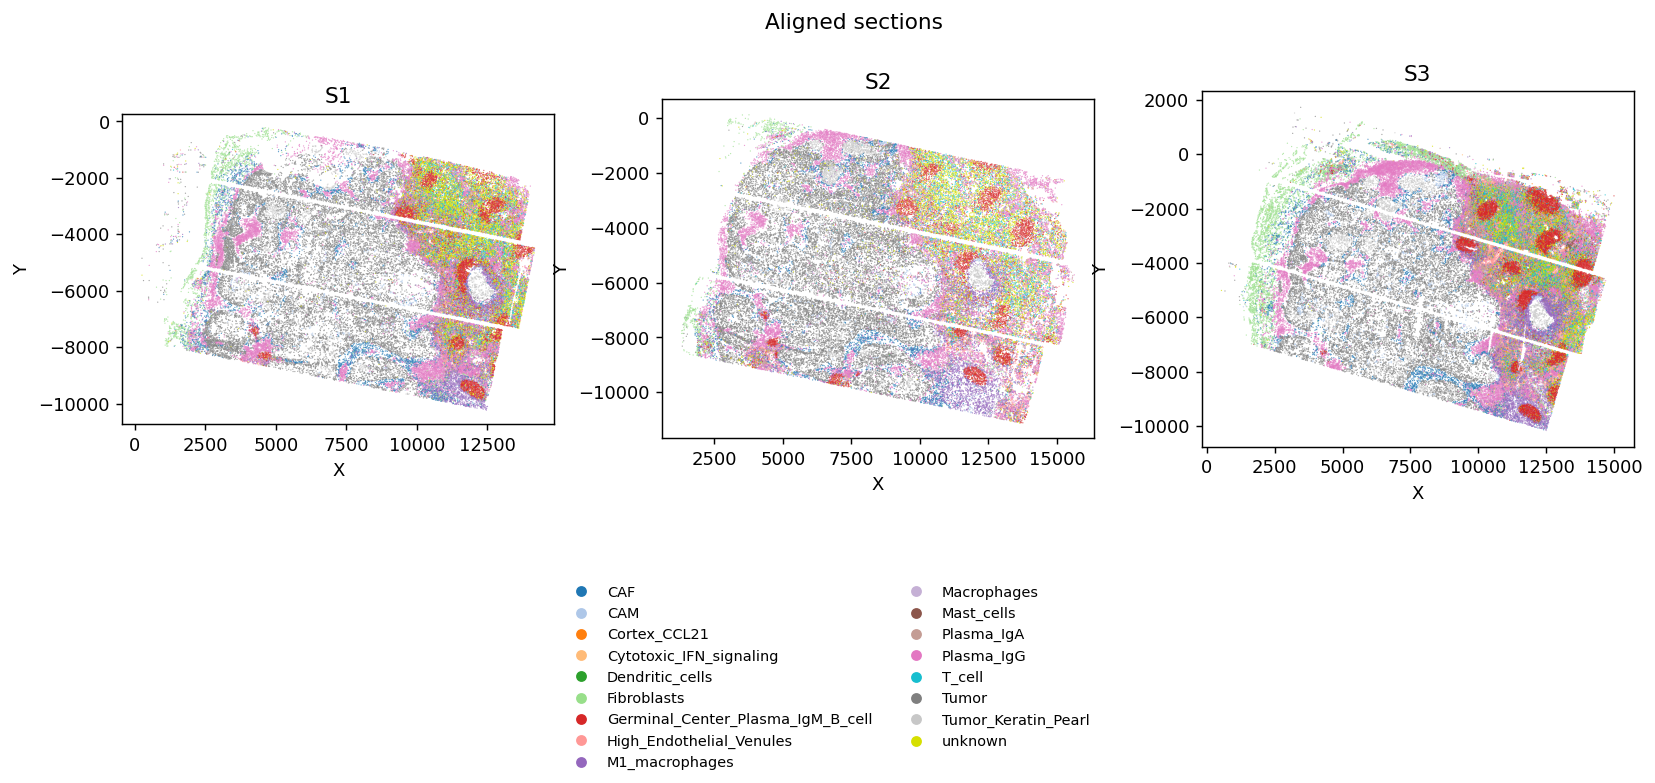

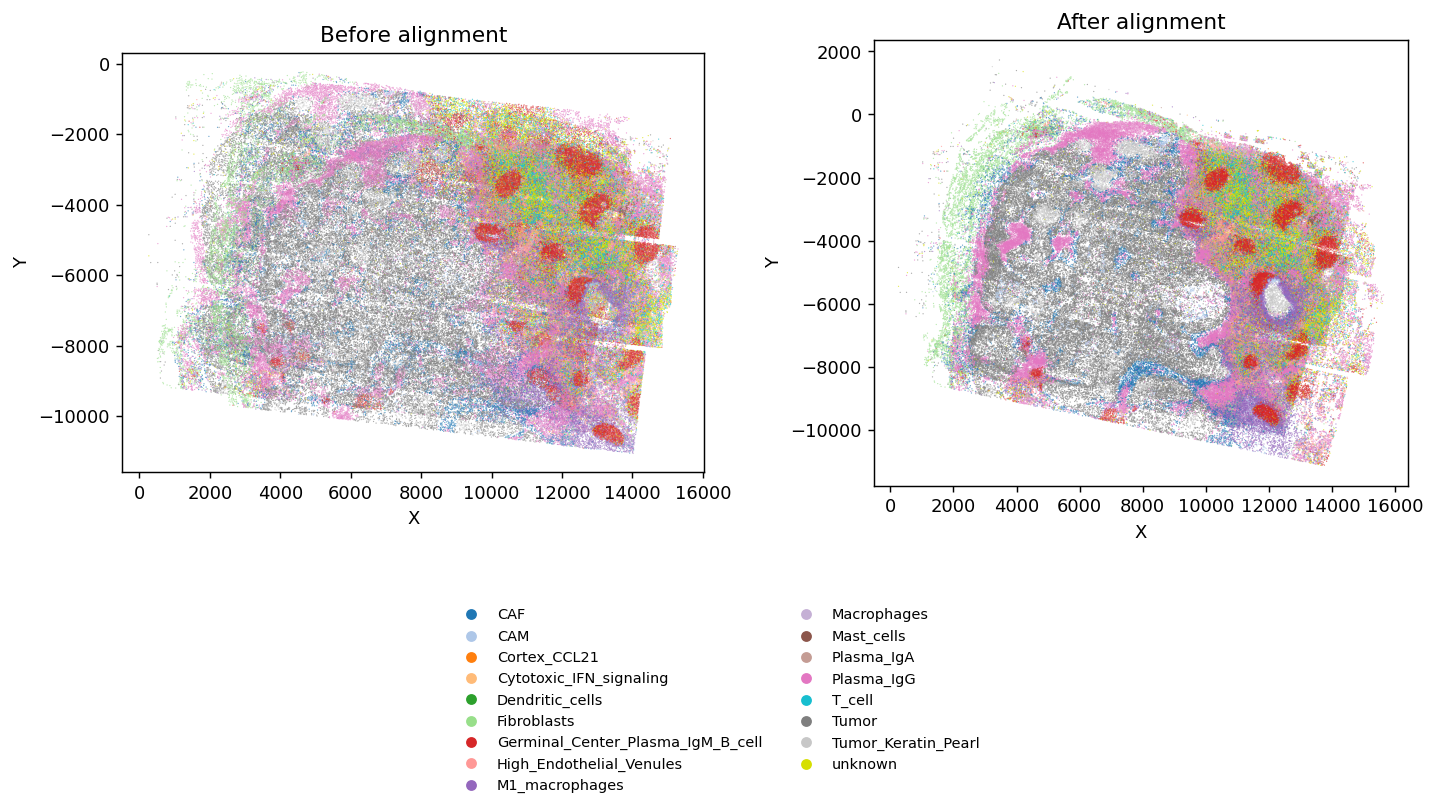

In [4]:
palette = annotation_palette(adata, "annotation", EXPERIMENT_DIR / "colors.json")
sample_panels(adata, adata.obsm["spatial"][:, :2], "sample", "annotation", palette, title="Original sections", size=.5);
sample_panels(adata, adata.obsm["spatial_3d_aligned"][:, :2], "sample", "annotation", palette, title="Aligned sections", size=.5);
alignment_overlay(adata, adata.obsm["spatial"][:, :2], adata.obsm["spatial_3d_aligned"][:, :2], "sample", "annotation", palette, size=.5);


In [5]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)


In [6]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000, batch_key="sample")


In [7]:
sc.tl.pca(adata)


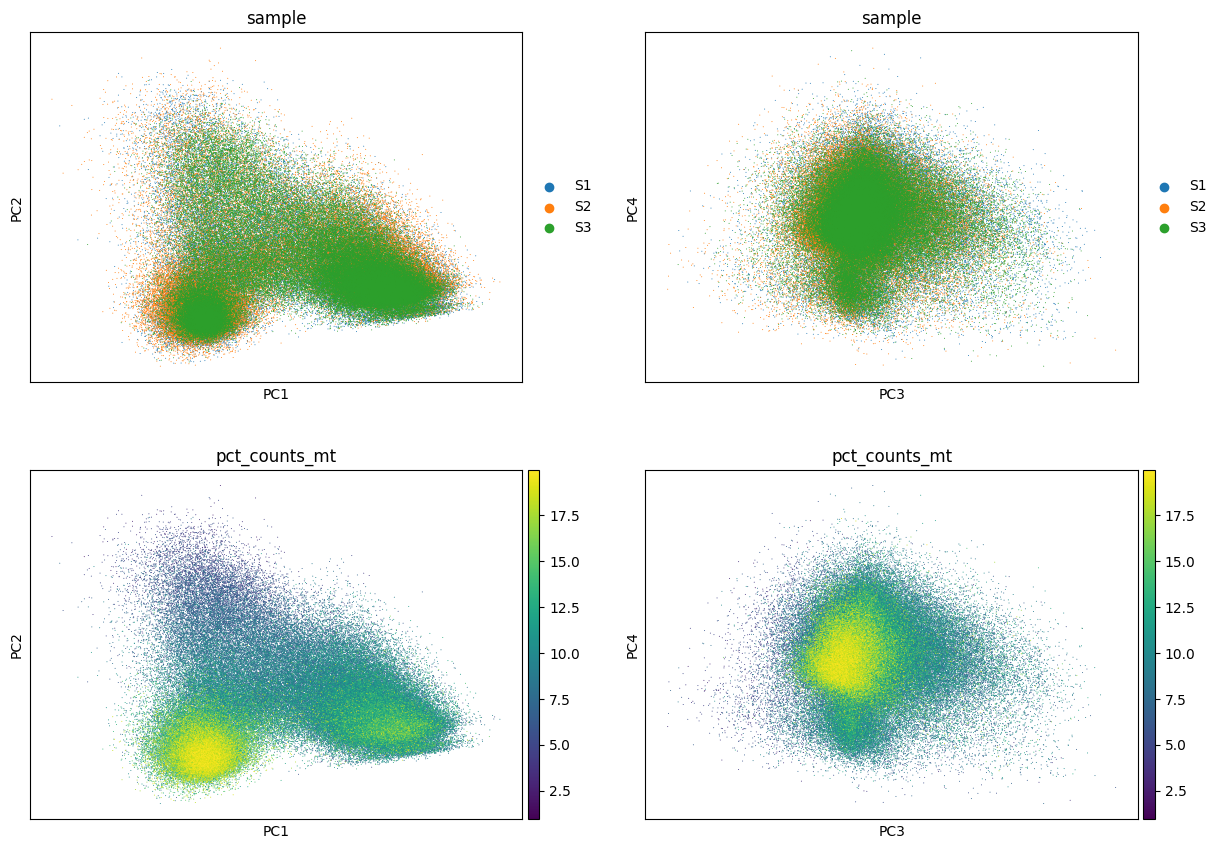

In [8]:
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)


In [9]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)


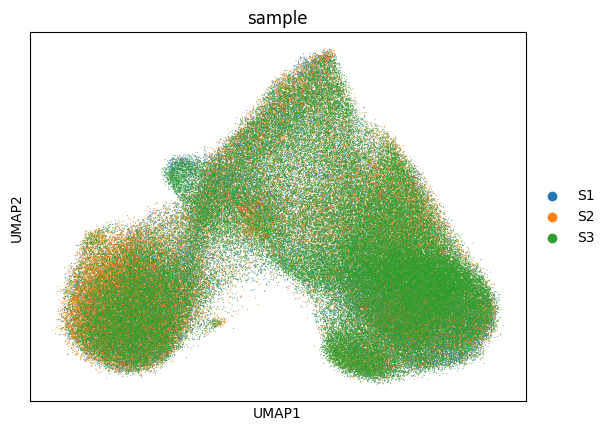

In [10]:
sc.pl.umap(adata, color="sample", size=2)


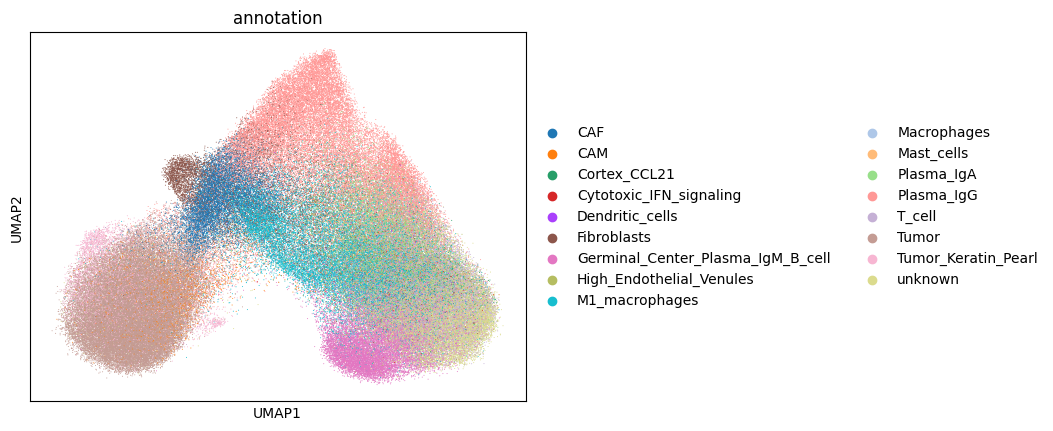

In [11]:
sc.pl.umap(adata, color="annotation", size=2)


## Train scanVI


In [12]:
scvi.model.SCANVI.setup_anndata(
    adata,
    layer="raw",
    labels_key="annotation",
    unlabeled_category="Unknown",   
    batch_key="sample"
)


In [13]:
model = scvi.model.SCANVI(adata)


In [14]:
model


ScanVI Model with the following params: 
unlabeled_category: Unknown, n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: zinb
Training status: Not Trained
Model's adata is minified?: False

In [15]:
model.train(**scanvi_train_kwargs)


INFO     Training for 43 epochs.                                                                                   


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=207` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=43` reached.


In [16]:
model_dir = SCANVI_DIR


In [17]:
model


ScanVI Model with the following params: 
unlabeled_category: Unknown, n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: zinb
Training status: Trained
Model's adata is minified?: False

In [18]:
SCVI_LATENT_KEY = "X_scanVI"

latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
latent.shape


(185673, 10)

In [19]:
# run PCA then generate UMAP plots
sc.tl.pca(adata)
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata)


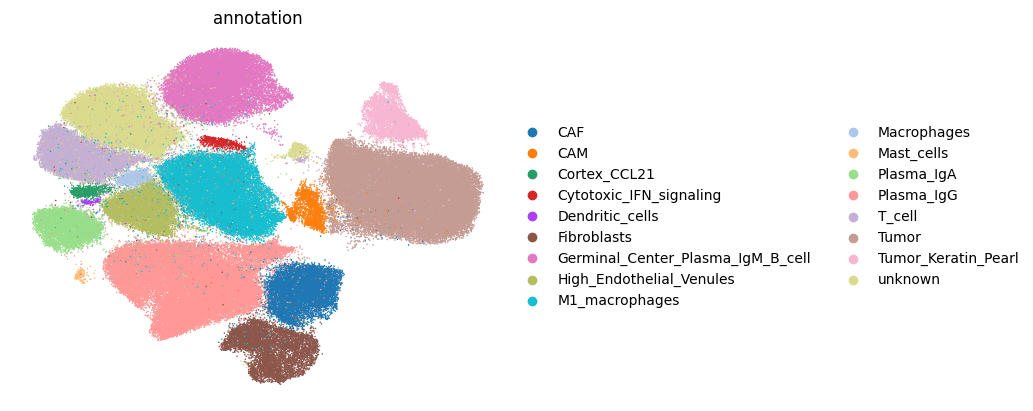

In [20]:
sc.pl.umap(adata,color=["annotation"],frameon=False,size = 5,)


In [21]:
adata.obs["cx_aligned"] = adata.obsm['spatial_3d_aligned'][:, 0].astype(np.float32)
adata.obs["cy_aligned"] = adata.obsm['spatial_3d_aligned'][:, 1].astype(np.float32)


## Save input


In [22]:
model.save(model_dir, overwrite=True, save_anndata=True)
print(f"Saved model-ready AnnData: {SCANVI_ADATA}")


Saved model-ready AnnData: /home/zhouyj/stVirtual_tutorial/experiments/HMLN/artifacts/checkpoints/scanvi/adata.h5ad


In [23]:
adata


AnnData object with n_obs × n_vars = 185673 × 28943
    obs: 'cell_ID_mask', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_reads', 'reads_per_counts', 'n_joined', 'exact_entropy', 'theoretical_entropy', 'exact_compression', 'theoretical_compression', 'n_counts', 'annotation', 'annotation_key', 'n_section', 'original_id_cleaned', 'sample_original', 'sample', '_scvi_batch', '_scvi_labels', 'cx_aligned', 'cy_aligned'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'sample_mapping', 'log1p', 'hvg', 'pca', 'sample_colors', 'neighbors', 'umap', 'annotation_colors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', 'spatial_3d_aligned', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'raw', 'counts'
    obsp: 'distances', 'connectivities'